In [1]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, acf
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV

In [2]:
data_curah_hujan_bulanan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\Data Gabung Curah Hujan Bulanan.csv")
data_banjir_kelurahan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\data_banjir_kelurahan_fix.csv").dropna(axis=1)

# Visualisasi Time Series

### Data Curah Hujan

In [3]:
data_curah_hujan_bulanan["tanggal"] = pd.to_datetime(data_curah_hujan_bulanan["tanggal"])
data_curah_hujan_bulanan = data_curah_hujan_bulanan.set_index("tanggal")

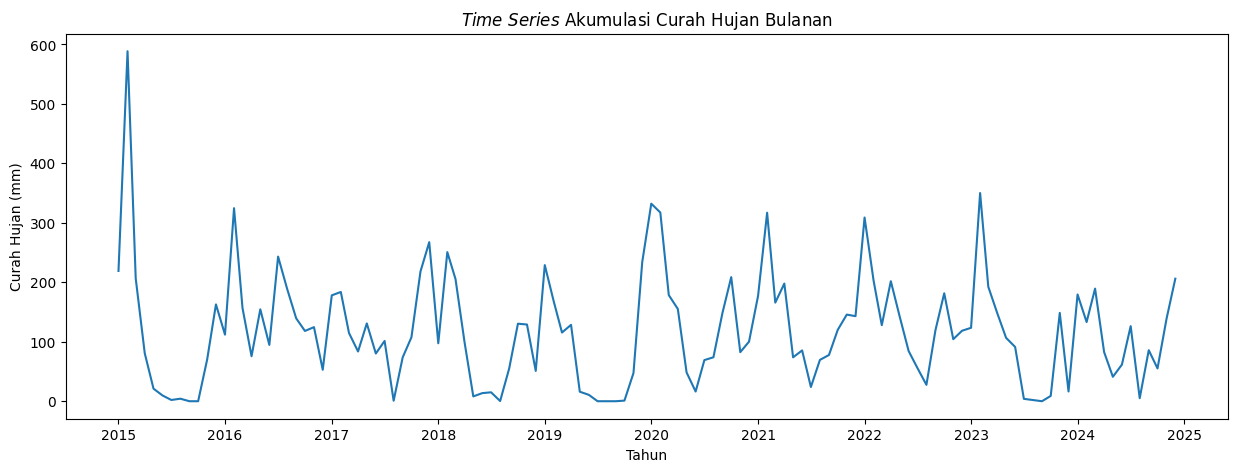

In [4]:
# Time Series Curah Hujan

plt.figure(figsize=(15, 5))
plt.plot(data_curah_hujan_bulanan.index, data_curah_hujan_bulanan["curah_hujan"])
plt.title(r"$\mathit{Time \ Series}$ Akumulasi Curah Hujan Bulanan")
plt.ylabel("Curah Hujan (mm)")
plt.xlabel("Tahun")
plt.show()

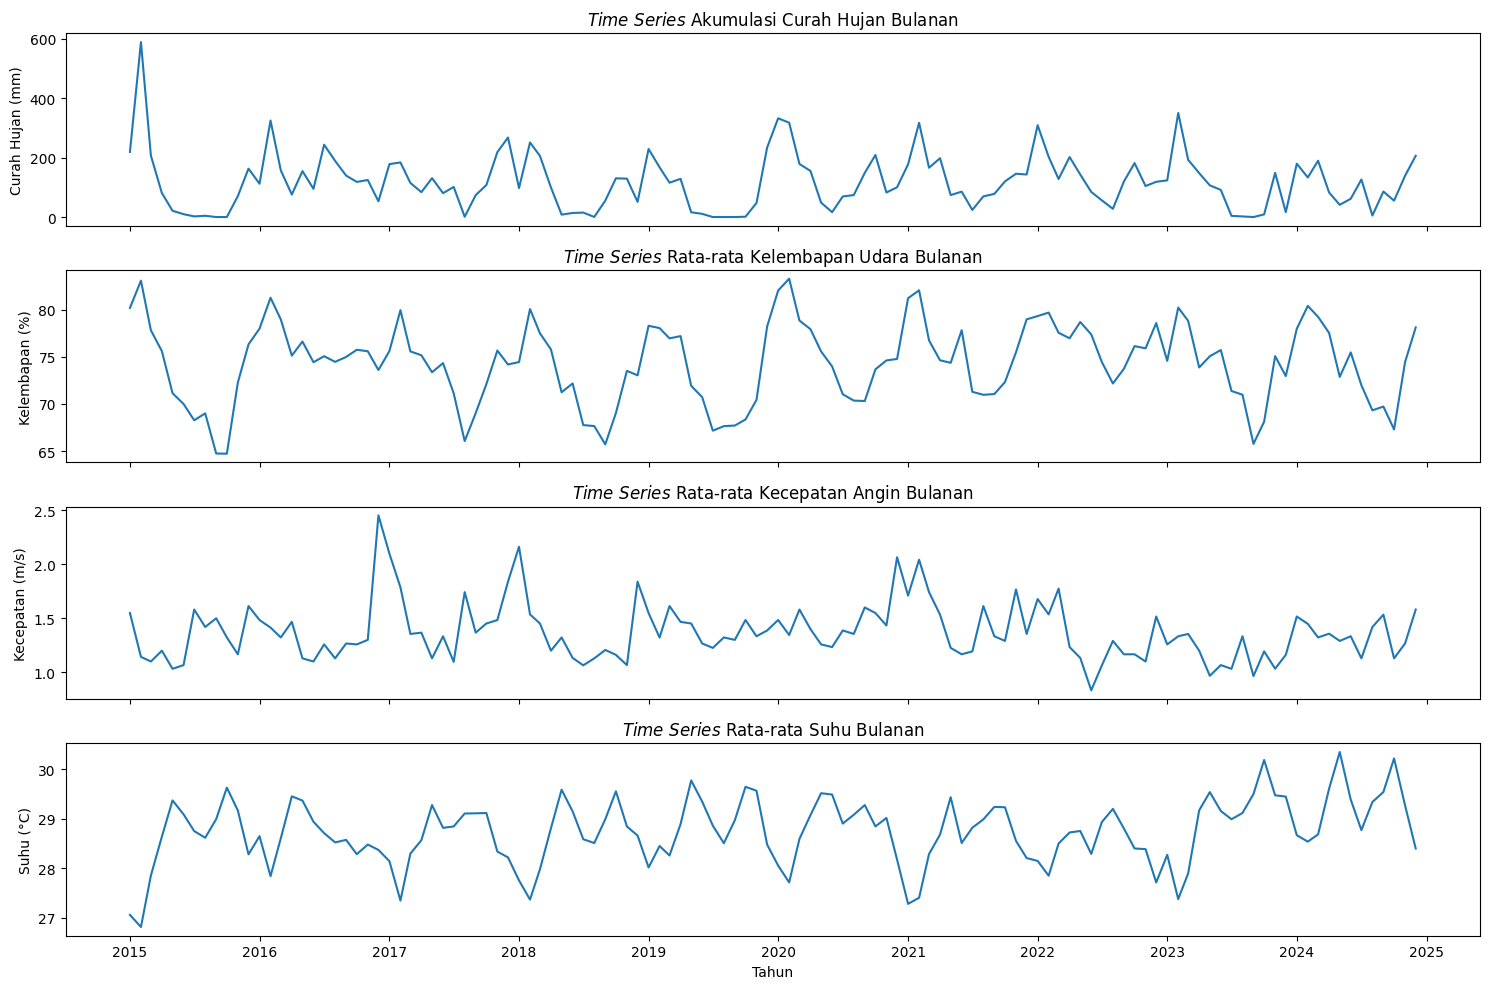

In [5]:
# Time Series Gabungan

fig, ax = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

ax[0].plot(data_curah_hujan_bulanan.index, data_curah_hujan_bulanan["curah_hujan"])
ax[0].set_title(r"$\mathit{Time \ Series}$ Akumulasi Curah Hujan Bulanan")
ax[0].set_ylabel("Curah Hujan (mm)")

ax[1].plot(data_curah_hujan_bulanan.index, data_curah_hujan_bulanan["kelembapan_udara"])
ax[1].set_title(r"$\mathit{Time \ Series}$ Rata-rata Kelembapan Udara Bulanan")
ax[1].set_ylabel("Kelembapan (%)")

ax[2].plot(data_curah_hujan_bulanan.index, data_curah_hujan_bulanan["kecepatan_angin"])
ax[2].set_title(r"$\mathit{Time \ Series}$ Rata-rata Kecepatan Angin Bulanan")
ax[2].set_ylabel("Kecepatan (m/s)")

ax[3].plot(data_curah_hujan_bulanan.index, data_curah_hujan_bulanan["suhu"])
ax[3].set_title(r"$\mathit{Time \ Series}$ Rata-rata Suhu Bulanan")
ax[3].set_ylabel("Suhu (°C)")
ax[3].set_xlabel("Tahun")

plt.tight_layout()
plt.show()

### Data Banjir

In [6]:
data_banjir_kelurahan["bulan"] = pd.to_datetime(data_banjir_kelurahan["bulan"], format="mixed")

data_banjir_kelurahan = data_banjir_kelurahan.set_index("bulan")

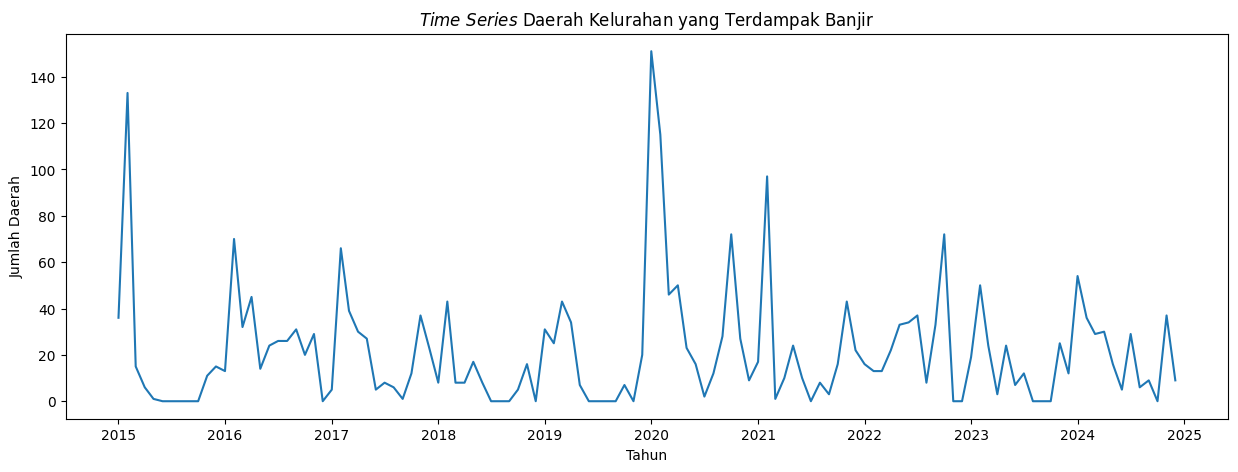

In [7]:
# Kelurahan
plt.figure(figsize=(15, 5))
plt.plot(data_banjir_kelurahan.index, data_banjir_kelurahan["TOTAL"])
plt.title(r"$\mathit{Time \ Series}$ Daerah Kelurahan yang Terdampak Banjir")
plt.ylabel("Jumlah Daerah")
plt.xlabel("Tahun")
plt.show()

### Overlay Curah Hujan dan Banjir

C:\Users\Giana\AppData\Local\Temp\ipykernel_34012\2237187911.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_banjir_kelurahan["total_banjir"] = data_banjir_kelurahan["TOTAL"]


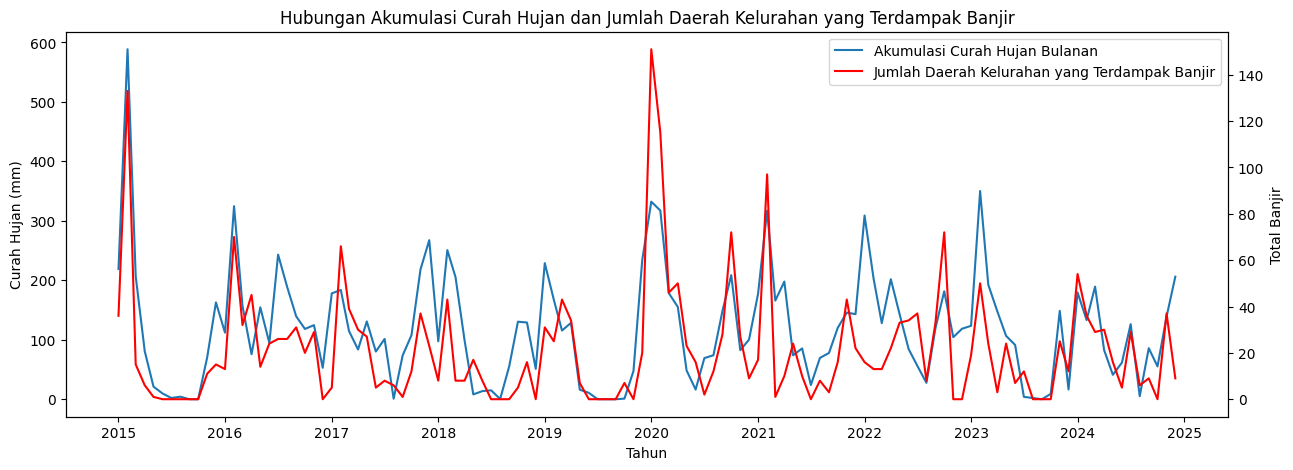

In [8]:
data_banjir_kelurahan["total_banjir"] = data_banjir_kelurahan["TOTAL"]
# data_banjir_kecamatan["total_banjir"] = data_banjir_kecamatan.sum(axis=1)

data_gabung_kelurahan = data_curah_hujan_bulanan.join(data_banjir_kelurahan[["total_banjir"]], how="inner")
# data_gabung_kecamatan = data_curah_hujan_bulanan.join(data_banjir_kecamatan[["total_banjir"]], how="inner")

# Kelurahan
fig1, ax11 = plt.subplots(figsize=(15, 5))
garis1 = ax11.plot(data_gabung_kelurahan.index, data_gabung_kelurahan["curah_hujan"])
ax11.set_ylabel("Curah Hujan (mm)")
ax11.set_xlabel("Tahun")

ax12 = ax11.twinx()
garis2 = ax12.plot(data_gabung_kelurahan.index, data_gabung_kelurahan["total_banjir"], color="red")
ax12.set_ylabel("Total Banjir")

garis1[0].set_label("Akumulasi Curah Hujan Bulanan")
garis2[0].set_label("Jumlah Daerah Kelurahan yang Terdampak Banjir")

semua_garis = garis1 + garis2
semua_label = [garis.get_label() for garis in semua_garis]
ax11.legend(semua_garis, semua_label, loc="upper right")

plt.title("Hubungan Akumulasi Curah Hujan dan Jumlah Daerah Kelurahan yang Terdampak Banjir")
plt.show()

In [9]:
# Menghitung korelasi Spearman
nilai_korelasi = data_gabung_kelurahan["curah_hujan"].corr(data_gabung_kelurahan["total_banjir"], method="spearman")

print(f"Nilai Korelasi Spearman antara Curah Hujan dan Banjir: {nilai_korelasi:.2f}")

Nilai Korelasi Spearman antara Curah Hujan dan Banjir: 0.69


In [17]:
# Membuat tabel peringkat (ranking)
df_rank = pd.DataFrame()
df_rank['Bulan'] = data_gabung_kelurahan['Bulan']
df_rank['Rank_Hujan (X)'] = data_gabung_kelurahan['curah_hujan'].rank()
df_rank['Rank_Banjir (Y)'] = data_gabung_kelurahan['total_banjir'].rank()
df_rank['di'] = df_rank['Rank_Hujan (X)'] - df_rank['Rank_Banjir (Y)']
df_rank['di2'] = df_rank['di']**2

# Tampilkan 5 data pertama untuk dicontek ke laporan
print(df_rank.head())

KeyError: 'Bulan'

In [ ]:
# Cara cari total d kuadrat untuk laporan
rank_x = data_gabung_kelurahan["curah_hujan"].rank()
rank_y = data_gabung_kelurahan["total_banjir"].rank()
d_kuadrat = (rank_x - rank_y)**2
print(f"Total d_i^2 adalah: {}")
print(f"Total Sigma d_i^2 adalah: {d_kuadrat.sum()}")

Total Sigma d_i^2 adalah: 89671.0


# Statistik Deskriptif

### Statistik curah hujan Bulanan

In [10]:
data_curah_hujan_bulanan.describe()

,curah_hujan,kelembapan_udara,kecepatan_angin,suhu
count,120.000000,120.000000,120.000000,120.000000
mean,118.299181,74.344956,1.372379,28.739801
std,95.032276,4.206055,0.263715,0.657420
min,0.000000,64.722581,0.833333,26.814286
25%,52.425000,71.216935,1.186828,28.362709
50%,109.754075,74.633333,1.333333,28.762151
75%,169.763506,77.550144,1.504032,29.177500
max,588.560036,83.300000,2.451613,30.348387


### Statistik banjir kelurahan

In [11]:
data_banjir_kelurahan.select_dtypes(include="number").sum(axis=1).describe()

count    120.000000
mean      65.125000
std       77.343125
min        0.000000
25%       15.000000
50%       45.000000
75%       90.000000
max      453.000000
dtype: float64

# Korelasi Curah Hujan

### Menggunakan ACF

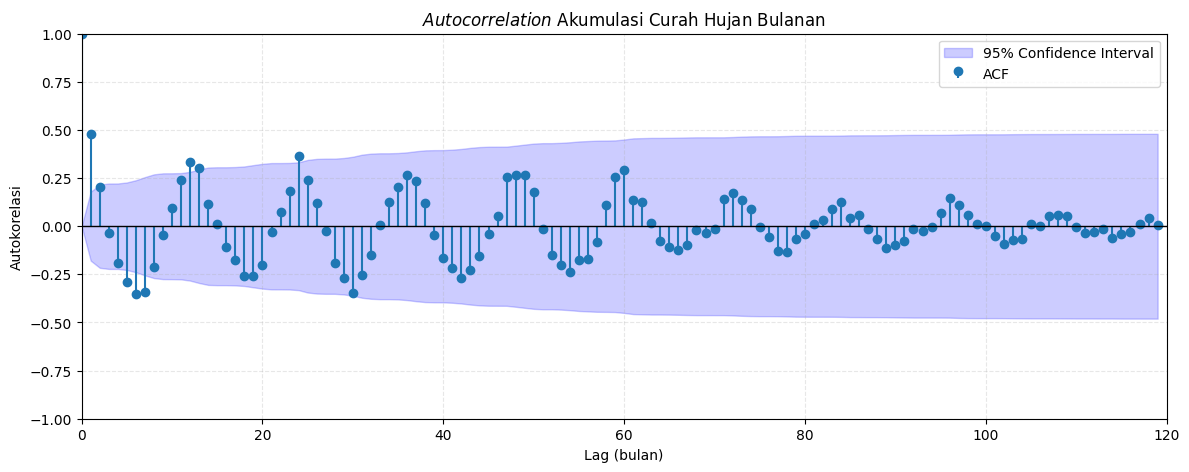

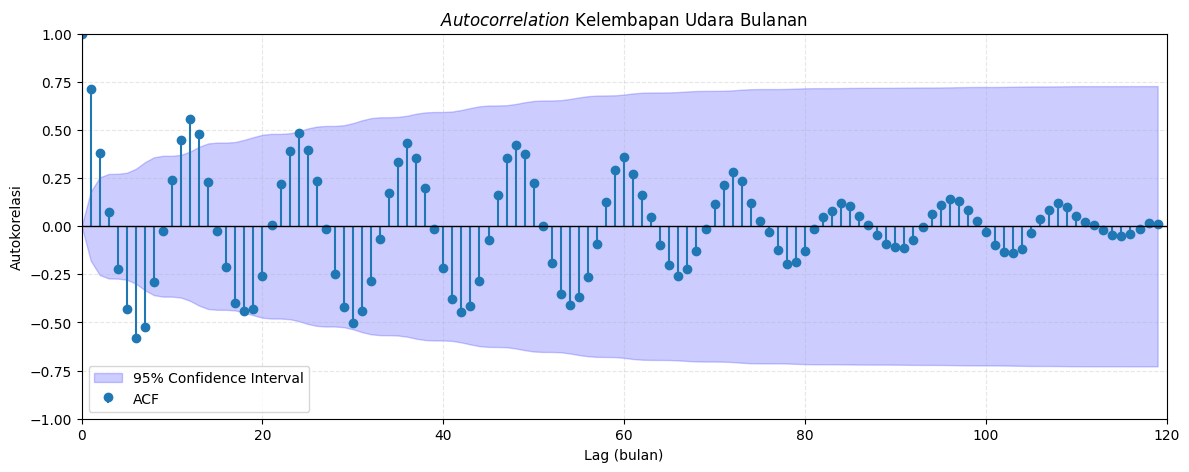

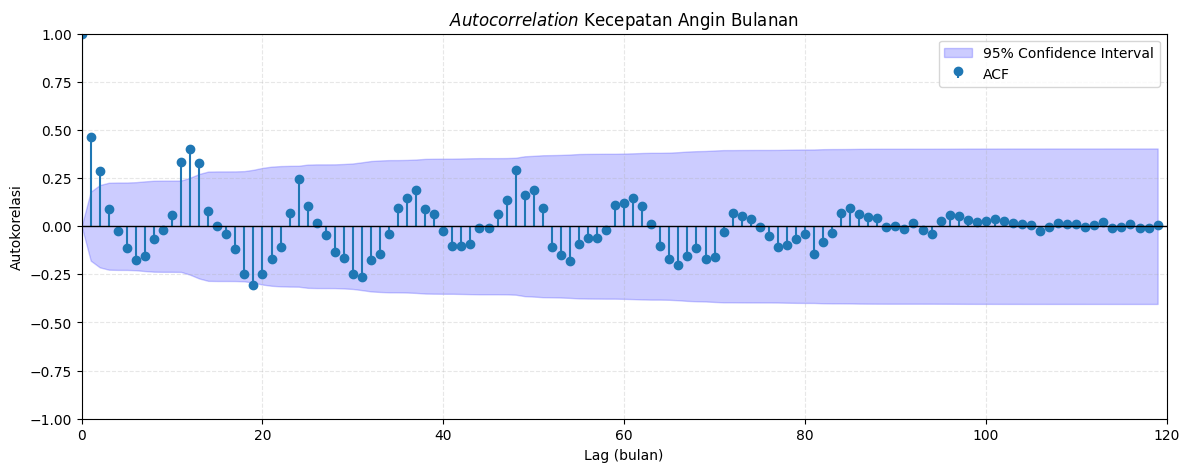

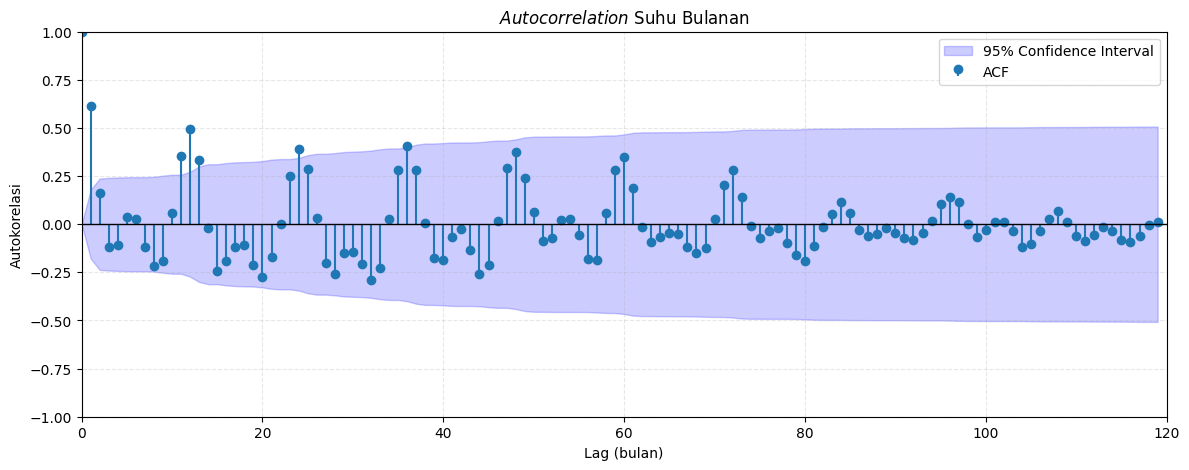

In [12]:
pengaturan_plot = [
    {"kolom": "curah_hujan", "judul": r"$\mathit{Autocorrelation}$ Akumulasi Curah Hujan Bulanan", "xlim": (0, 120), "ylim": (-1, 1)},
    {"kolom": "kelembapan_udara", "judul": r"$\mathit{Autocorrelation}$ Kelembapan Udara Bulanan", "xlim": (0, 120), "ylim": (-1, 1)},
    {"kolom": "kecepatan_angin", "judul": r"$\mathit{Autocorrelation}$ Kecepatan Angin Bulanan", "xlim": (0, 120), "ylim": (-1, 1)},
    {"kolom": "suhu", "judul": r"$\mathit{Autocorrelation}$ Suhu Bulanan", "xlim": (0, 120), "ylim": (-1, 1)}
]

for plot in pengaturan_plot:
    data_bersih = data_curah_hujan_bulanan[plot["kolom"]].dropna().values
    
    acf_vals, confint = acf(data_bersih, nlags=120, fft=True, alpha=0.05)
    
    lower_bound = confint[:, 0] - acf_vals
    upper_bound = confint[:, 1] - acf_vals
    lags = range(len(acf_vals))
    
    plt.figure(figsize=(14, 5))
    plt.fill_between(lags, lower_bound, upper_bound, color='blue', alpha=0.2, label='95% Confidence Interval')
    plt.stem(lags, acf_vals, basefmt=" ", label='ACF')
    plt.axhline(0, color='black', linewidth=1)
    plt.xlim(plot["xlim"])
    plt.ylim(plot["ylim"])
    plt.xlabel("Lag (bulan)")
    plt.ylabel("Autokorelasi")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.title(plot["judul"])
    plt.legend()
    plt.show()

### Korelasi antarvariabel

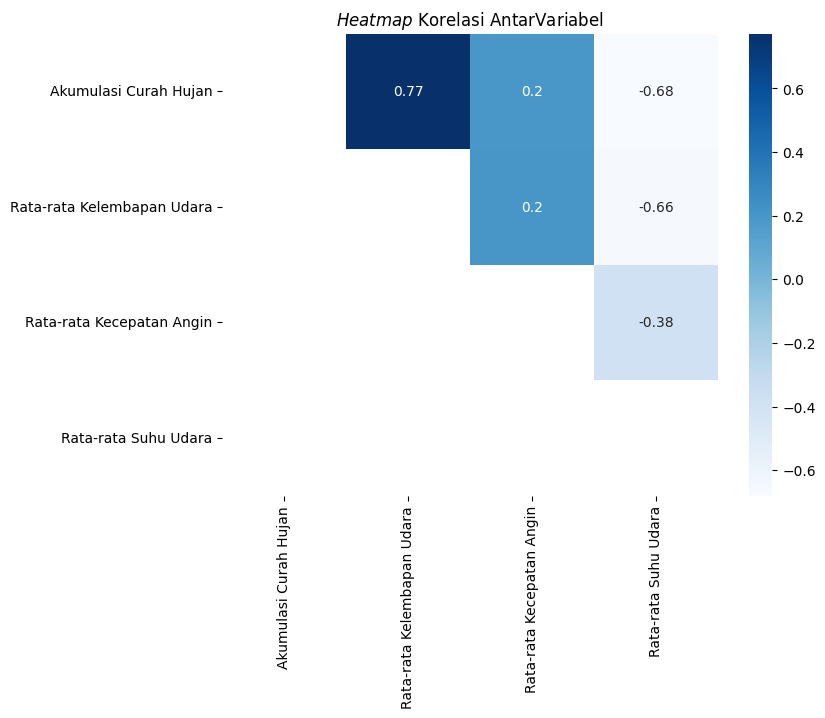

In [13]:
plt.figure(figsize=(8, 6))
corr_data = (data_curah_hujan_bulanan[["curah_hujan",
                      "kelembapan_udara",
                      "kecepatan_angin",
                      "suhu"]].rename(columns={
                          "curah_hujan": "Akumulasi Curah Hujan",
                          "kelembapan_udara": "Rata-rata Kelembapan Udara",
                          "kecepatan_angin": "Rata-rata Kecepatan Angin",
                          "suhu": "Rata-rata Suhu Udara"})).corr()
sns.heatmap(corr_data, mask=np.tril(np.ones_like(corr_data, dtype=bool)), annot=True, cmap="Blues"
)

plt.title(r"$\mathit{Heatmap}$ Korelasi AntarVariabel")
plt.show()